# すべてをまとめて実行

## インストール、インポート

In [ ]:
!pip install quantecon
!pip install numba
!pip install interpolation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 kB 2.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
from quantecon.optimize import brentq
from quantecon.markov import rouwenhorst, tauchen
from interpolation import interp
from numba import njit, guvectorize
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import scipy

## Aiyagariの設定

### Calibration

In [ ]:
# パラメータ
beta = 0.96
gamma = 1.0
rho = 0.9
sigma = 0.4*np.sqrt((1-rho**2))
alpha = 0.36
delta = 0.08
b = 0

### 政策関数の計算のための関数

In [ ]:
# Maliarグリッド

@njit
def maliar_grid(a_min, a_max, N, theta):
		a_grid = np.empty(N)
		for i in range(1,N+1):
				a_grid[i-1] = a_min + (a_max - a_min)*((i-1)/(N-1))**theta

		return a_grid

In [ ]:
# exponentialグリッド

@njit
def exponential_grid(a_min, a_max, N):
    """
    対数空間を使ったグリッド生成関数
    Parameters:
        a_min: float, グリッドの最小値
        a_max: float, グリッドの最大値
        N: int, グリッドの分割数
    Returns:
        grid: np.ndarray, 生成されたグリッド
    """
    # 対数変換
    log_a_min = np.log1p(a_min)  # log(1 + a_min)
    log_a_max = np.log1p(a_max)  # log(1 + a_max)

    # 等間隔のグリッドを生成
    log_grid = np.linspace(log_a_min, log_a_max, N)

    # 再変換して結果を格納
    grid = np.expm1(log_grid)  # exp(x) - 1
    return grid

In [ ]:
# 補間のための関数（外挿あり, ベクトルとして出力）
@guvectorize(['void(float64[:], float64[:], float64[:], float64[:])'], '(n),(nq),(n)->(nq)')
def interpolate_y(x, xq, y, yq):
    """Efficient linear interpolation exploiting monotonicity.
    Extrapolates linearly when xq out of domain of x.
    """
    nxq, nx = xq.shape[0], x.shape[0]

    xi = 0
    x_low = x[0]
    x_high = x[1]
    for xqi_cur in range(nxq):
        xq_cur = xq[xqi_cur]
        while xi < nx - 2:
            if x_high >= xq_cur:
                break
            xi += 1
            x_low = x_high
            x_high = x[xi + 1]

        xqpi_cur = (x_high - xq_cur) / (x_high - x_low)
        yq[xqi_cur] = xqpi_cur * y[xi] + (1 - xqpi_cur) * y[xi + 1]

In [ ]:
# 補間のための関数（外挿あり, スカラーとして出力）
from numba import njit

@njit
def interp_scalar(xq, x, y):
    """
    x:   グリッド (n,)
    y:   グリッド値 (n,)
    xq:  補間したい点（スカラー）
    return: 線形補間（外挿は端点値）
    """
    n = x.shape[0]
    # 外挿
    if xq <= x[0]:
        return y[0]
    elif xq >= x[n-1]:
        return y[n-1]
    # 二分探索で区間を見つける
    lo = 0
    hi = n-1
    while hi - lo > 1:
        mid = (lo + hi) // 2
        if x[mid] > xq:
            hi = mid
        else:
            lo = mid
    # 線形補間
    w = (x[hi] - xq) / (x[hi] - x[lo])
    return w * y[lo] + (1.0 - w) * y[hi]

In [ ]:
# 解く問題の設定を行う（パラメータ, グリッド, 効用関数や生産関数）
# モデルを変更する場合にはここを修正
class Setting:

    def __init__(self,
                 R=1.01,                          # 粗実質利子率
                 beta=0.99,                          # 割引因子
                 gamma=1,                          # 相対的リスク回避度(異時点間の代替弾力性の逆数)
                 delta = 0.08,                    # 資本減耗率
                 b=3,                             # 内生的な状態変数の最小値, 借入制約
                 a_max=16,                        # 内生的な状態変数の最大値
                 na=21,                           # 内生的な状態変数のグリッド数
                 na_sd = 800,                     # 定常分布における資本のグリッド数
                 tau = 0.1,                       # 資本課税率
                 Xi = 0.1,                        # 所得移転額
                 mu=0,                            # 外生変数のAR(1)過程の定数項
                 rho=0.6,                        # 外生変数のAR(1)過程の慣性
                 sigma=0.4,                       # 外生変数のAR(1)過程のショック項の標準偏差
                 nz = 11,                         # 外生変数のグリッド数
                 w = 0,                         # 賃金
                 lambdaPF = 1):                 # 政策関数の更新度


        # パラメータを設定する
        self.R = R
        self.beta = beta
        self.b = b
        self.gamma = gamma
        self.delta = delta

        self.na = na
        self.nz = nz
        self.na_sd = na_sd

        self.tau = tau
        self.Xi = Xi


        # 外生変数の遷移確率とグリッドを設定する

        #1 rowenhorst
        # mc = rouwenhorst(nz, rho, sigma, mu)
        # self.Pz = mc.P
        # self.z_grid = np.exp(mc.state_values)

        #2 tauchen
        mc = tauchen(nz, rho, sigma, mu, n_std = 3)
        self.Pz = np.array(mc.P)
        if mc.state_values is None:
           raise ValueError("mc.state_values is None, cannot apply np.exp.")
        self.z_grid = np.exp(mc.state_values)


        # 内生的な状態変数のグリッドを設定する
        # a_grid = np.linspace(-b, a_max, na)
        #a_grid = maliar_grid(-b, a_max, na, 2)
        a_grid = exponential_grid(-b, a_max, na)
        self.a_grid = a_grid

        # 定常分布用のグリッドを用意
        a_grid_sd = np.linspace(-b, a_grid[-1], na_sd)
        #a_grid_sd = maliar_grid(-b , a_grid[-1], na_sd, 2)
        self.a_grid_sd = a_grid_sd


        # 賃金を設定
        self.w = w

        # 政策関数の更新度を設定する
        self.lambdaPF = lambdaPF

        # CRRA型効用関数と限界効用を定義する
        gamma = self.gamma
        if gamma == 1:
            self.utility = np.log
            self.mutility = njit(lambda x: 1 / x)
        else:
            self.utility = njit(lambda x: x**(1-gamma) / (1 - gamma))
            self.mutility = njit(lambda x: x**(-gamma))


		    # 政策関数の初期値を定義する
        z_grid = self.z_grid
        hfun_old = np.empty((len(a_grid), len(z_grid)))
        for i_a, a in enumerate(a_grid):
            for i_z, z in enumerate(z_grid):
                c_max = 0.5* (R * a + w * z + Xi + b)
                hfun_old[i_a, i_z] = c_max
        self.hfun_old = hfun_old


# 特定のアルゴリズムを実行して政策関数を更新する関数を出力する
# FOCを変更する場合やアルゴリズムを変更する場合はここを修正

# 今期の状態変数について繰り返し記号はi, 来期の状態変数について繰り返し記号はj

def EGMIterationWithGov(hp): # hpはSettingクラスからつくられるインスタンス

    # インスタンスからローカル変数を定義する
    R, beta, b, gamma, mutility, tau, delta  = hp.R, hp.beta, hp.b, hp.gamma, hp.mutility, hp.tau, hp.delta
    a_grid, z_grid, Pz, w, Xi = hp.a_grid, hp.z_grid, hp.Pz, hp.w, hp.Xi

    R_net = R - tau - delta # after-tax interest

    @njit
    def UpdatePF(h_old):

        h_new = np.empty_like(h_old)
        a_tilde = np.empty_like(a_grid)
        aprime_new = np.empty_like(a_grid)

        for i_z in range(len(z_grid)): # 今期の生産性について繰り返し
            z = z_grid[i_z]

            for j_a in range(len(a_grid)): # 来期の資産について繰り返し
                aprime = a_grid[j_a]

                expectation = 0
                for j_z in range(len(z_grid)): # 来期の生産性について繰り返し

                    # オイラー方程式の右辺を計算する
                    expectation += mutility(h_old[j_a, j_z]) * Pz[i_z, j_z]

                rhs = R_net * beta * expectation
                c_tilde = rhs**(-1.0/gamma)

                # 今期の資産を計算
                a_tilde[j_a] = (aprime - z*w - Xi + c_tilde)/R_net


            # 来期の資産の政策関数をinterpolationで求める
            interpolate_y(a_tilde, a_grid, a_grid, aprime_new)

            for i_a in range(len(a_grid)): # 今期の資産について繰り返し

                # 来期の資産の政策関数をinterpolationで求める
                #aprime_new = interp(a_tilde, a_grid, a_grid[i_a])

                # 借り入れ制約を考慮しつつ来期の資産を求める
                if aprime_new[i_a] < -b:
                    aprime_new[i_a] = -b
                else:
                    aprime_new[i_a] = aprime_new[i_a]

                # 消費の政策関数を求める
                h_new[i_a,i_z] = R_net * a_grid[i_a] + z*w + Xi - aprime_new[i_a]

        return h_new

    return UpdatePF



# メイン関数：特定のアルゴリズムでiterationを行い、問題を解く関数
# 基本的には変更する必要がない

def SolveProblem(hp,               # Settingクラスからつくられるインスタンス
                Algorithm,         # アルゴリズムを指定
                tol=1e-8,          # 許容繰り返し誤差
                max_iter=20000,     # iteration回数の最大値
                verbose=True,      # 進捗を表示するかどうか
                print_skip=25):    # 進捗を何回ごとに表示するか


    # インスタンスからローカル変数を定義する
    # R, beta, b, mutility = hp.R, hp.beta, hp.b, hp.mutility
    # a_grid, z_grid, Pz = hp.a_grid, hp.z_grid, hp.Pz
    lambdaPF = hp.lambdaPF
    hfun_old = hp.hfun_old

    # チェックのために外生変数のグリッドと遷移確率を表示する
    # print(f"About exogenous variables:")
    # print(f"grid is {z_grid}.")
    # print(f"Transition matrix is {Pz}.")



    # 政策関数を更新する関数を取得する
    UpdatePF = Algorithm(hp)

    # iterationを行い、問題を解く
    i = 0
    error = tol + 1

    while i < max_iter and error > tol:

        # 政策関数を更新する
        hfun_new_tilde = UpdatePF(hfun_old)

        # 古い政策関数と加重平均する
        hfun_new = lambdaPF*hfun_new_tilde + (1-lambdaPF)*hfun_old

        error = np.max(np.abs(hfun_new-hfun_old))
        i += 1
        if verbose and i % print_skip == 0:      # 進捗をprint_skip回ごとに表示する
            print(f"PF Error at iteration {i} is {error}.")
        hfun_old = hfun_new

    if i == max_iter:
        print("Failed to converge!")

    if verbose and i < max_iter:
        print(f"\nConverged in {i} iterations.")

    return hfun_new

### 定常分布の計算のための関数

In [ ]:
from numba import njit
import numpy as np


@njit
def gridlookup2(x0, xgrid):
    nx = np.shape(xgrid)[0]
    ix = 0
    for jx in range(nx):
        if x0 <= xgrid[jx]:
            break
        ix += 1
    ix = min(max(1, ix), nx-1)
    return ix - 1


@njit
def solve_sd(mu0: np.ndarray,
                        na: int,
                        nz: int,
                        na_sd: int,    # mu0.shape[0]のこと
                        agrid: np.ndarray,
                        agrid_sd: np.ndarray,
                        Pz: np.ndarray,
                        pfgrid: np.ndarray,
                        critmu: float = 1e-6):


    # -1. 政策関数の行列を補間して、行数を na 個から na_sd 個に変える
    # pfgrid -> pfgrid_new
    pfgrid_new = np.empty((na_sd,nz))              # 空の箱を用意
    for z_index in range(nz):
      aprime_new = np.empty(na_sd)
      interpolate_y(agrid, agrid_sd, pfgrid[:, z_index], aprime_new)
      pfgrid_new[:,z_index] = aprime_new


    # 0. transition matrixを計算
    G = np.zeros((na_sd*nz,na_sd*nz))
    weight = np.zeros((na_sd,nz))

    for iz in range(nz):
      for ia in range(na_sd):

        # 政策関数 pfgrid[ia, iz] に合わせる
        aprime = pfgrid_new[ia, iz]


        if aprime < agrid_sd[0]:
            weight[ia, iz] = 1.0
            jtilde = 0
        elif aprime > agrid_sd[-1]:
            weight[ia, iz] = 0
            jtilde = na_sd - 2
        else:
          # aprimeが落ちる区間の左端のグリッドのインデックスを探す
          jtilde = gridlookup2(aprime, agrid_sd)
          # 重み weight[ia, iz] に格納
          weight[ia, iz] = (agrid_sd[jtilde+1] - aprime) / (agrid_sd[jtilde+1] - agrid_sd[jtilde])

        # スタックしたときの現在の状態のインデックスを計算
        i_s = iz * na_sd + ia

        # 次期外生状態 jz でループ
        for jz in range(nz):

            # スタックしたときの次期の状態のインデックスを計算
            j_s  = jz * na_sd + jtilde

            # 遷移確率行列 G に代入
            #   - Pe[iz, jz] : 現在 iz から次期 jz への外生ショックの遷移確率
            G[i_s, j_s ] += weight[ia, iz]   * Pz[iz, jz]
            G[i_s, j_s + 1] += (1.0 - weight[ia, iz]) * Pz[iz, jz]


    # 1. 分布をiterationで求める
    diffmu = 1.0e4


    # 分布の初期値をスタックしてベクトル化
    mu0 = mu0.T.flatten()
    mu0 = mu0 / np.sum(mu0)
    mu1 = np.zeros(na_sd*nz)

    while diffmu > critmu:

        # 1. 分布の更新 : dist_new = G' * dist
        mu1 = G.T @ mu0

        # 2. 収束判定
        diffmu = np.max(np.abs(mu1 - mu0))

        # 3. normalizeして次のループへ
        mu0 = mu1 / np.sum(mu1)

    sd = mu0.reshape(nz, na_sd).T
    return sd


### 総労働供給を求める

In [ ]:
# 生産性の定常分布を求める

hp = Setting(beta=beta, gamma = gamma, b = b, a_max = 200, lambdaPF = 1, na = 200, na_sd = 200, nz = 7, rho = rho, sigma = sigma) # 生産性の定常分布を求めるために必要ない変数については初期値のまま

muZ_old = np.ones(len(hp.z_grid)) / len(hp.z_grid)

tol=1E-11
maxit=100^4

for it in range(maxit):
  muZ_new = muZ_old @ hp.Pz
  if np.max(np.abs(muZ_new - muZ_old)) < tol: break
  muZ_old = muZ_new

# 総労働供給を求める
Lbar = sum(muZ_new*hp.z_grid)
print(Lbar)

1.115492422604271


## 初期定常状態(ini)実行

In [ ]:
import time

start_time = time.time()  # 計測開始

# 税率を設定
tau = 0

# 資本ストックと所得移転のguess
K0d = 6.0* Lbar
Xi0 = tau * K0d

# ループの初期化
diff_KL = 1
diff_rev = 1
loop = 0




while abs(diff_KL) > 1e-8 or abs(diff_tax) > 1e-6:
    loop += 1
    # print("loop: ", loop)

    # 1 実質金利と賃金を更新
    r0 = alpha*(K0d/Lbar)**(alpha-1)
    w0 = (1 - alpha) * (K0d/Lbar) ** alpha


    # 2 消費の政策関数 hfun_c を求める
    hp = Setting(beta=beta, gamma = gamma, b = b, a_max = 250, lambdaPF = 1, na = 200, na_sd = 200, nz = 7, rho = rho, sigma = sigma, R = 1 + r0, w = w0, Xi = Xi0, tau=tau, delta = delta)
    hfun_c = SolveProblem(hp,EGMIterationWithGov)

    # 3
    # hfun_c から 次期のアセット aprime の政策関数を求める
    hfun_aprime = np.empty((len(hp.a_grid), len(hp.z_grid)))
    a_mesh, z_mesh = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij') # ユニバーサル関数を使用するためのグリッドを生成
    R_net = 1.0 + r0 - tau - delta
    hfun_aprime = R_net * a_mesh + hp.w * z_mesh + hp.Xi - hfun_c



    # 初期の定常分布を定義
    sd_grid = np.full((hp.na_sd, hp.nz), 1 / (hp.na_sd * hp.nz))

    # 4 状態分布を更新する
    sd = solve_sd(sd_grid, hp.na, hp.nz, hp.na_sd, hp.a_grid, hp.a_grid_sd, hp.Pz, hfun_aprime, critmu = 1e-8)

    # 5 更新された状態分布から資本ストックの総供給を求める
    Amesh, _ = np.meshgrid(hp.a_grid_sd, hp.z_grid, indexing='ij')
    K0s = np.sum(Amesh * sd)
    # # --- hfun_aprime を補間 ---
    # hfun_aprime_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
    # for iz in range(len(hp.z_grid)):
    #     interpolate_y(hp.a_grid, a_grid_sd, hfun_aprime[:, iz], hfun_aprime_interp[:, iz])
    # # 総資本ストック供給 K_s の計算
    # K0s = np.sum(hfun_aprime_interp * sd)

    # 6 資本ストックを更新
    print("K0s: ", K0s)
    diff_KL = (K0s/Lbar - K0d/Lbar)
    print("diff_KL: ", diff_KL)

    KdL = 0.95*K0d/Lbar + (1-0.95)*K0s/Lbar
    K0d = KdL * Lbar

    # 7 税収を計算して所得移転を更新
    tax = tau * K0s

    diff_tax = tax - Xi0
    print("diff_tax: ", diff_tax)
    Xi0 = 0.5*Xi0 + (1-0.5)*tax

end_time = time.time()  # 計測終了

print("Elapsed time:", end_time - start_time, "seconds")

PF Error at iteration 25 is 0.34317233531345437.
PF Error at iteration 50 is 0.06883690644971807.
PF Error at iteration 75 is 0.020198449935861618.
PF Error at iteration 100 is 0.006557440323973651.
PF Error at iteration 125 is 0.0021816205195079874.
PF Error at iteration 150 is 0.0007229436230034025.
PF Error at iteration 175 is 0.00023504574372168463.
PF Error at iteration 200 is 7.39356900396615e-05.
PF Error at iteration 225 is 2.207855885671961e-05.
PF Error at iteration 250 is 6.1309537215947785e-06.
PF Error at iteration 275 is 1.5718253791874304e-06.
PF Error at iteration 300 is 3.7607429703712114e-07.
PF Error at iteration 325 is 8.55191899518104e-08.
PF Error at iteration 350 is 1.8792803757605725e-08.

Converged in 361 iterations.
K0s:  7.342972075798477
diff_KL:  0.582718023897729
diff_tax:  0.0
PF Error at iteration 25 is 0.3429049785829079.
PF Error at iteration 50 is 0.0686856200436523.
PF Error at iteration 75 is 0.02010281965510785.
PF Error at iteration 100 is 0.00650

In [ ]:
sd_ini =  sd
k_ini = K0d

w = (1 - alpha) * (K0d/Lbar) ** alpha
w_ini = w
r_ini = r0


xi_ini = tau * K0d

aprime_ini = hfun_aprime

c_ini = hfun_c

print(r_ini-delta)
print(k_ini/Lbar)

0.03375448757026252
6.05022904568319


In [ ]:
# --- 労働市場均衡の確認 ---
# 労働需要の計算
L_demand = (w0 / ((1 - alpha) * K0d ** alpha)) ** (-1 / alpha)
# 労働市場誤差の計算
labor_market_error = L_demand - Lbar
print("労働市場誤差",labor_market_error)
# 労働供給の計算
# Lbarをつかう


# --- 財市場均衡の確認 ---
# 総産出 Y の計算
# 財の供給側
Y = (K0d ** alpha) * (L_demand ** (1 - alpha))

#　財の需要側
# --- hfun_c を補間 ---
hfun_c_interp = np.empty((len(hp.a_grid_sd), len(hp.z_grid)))
for iz in range(len(hp.z_grid)):
    interpolate_y(hp.a_grid, hp.a_grid_sd, hfun_c[:, iz], hfun_c_interp[:, iz])

# 総消費 C の計算
C = np.sum(hfun_c_interp * sd)

# 総投資 I の計算
#I = delta * K0s
# 財市場の均衡誤差
goods_market_error = C - (Y - delta * K0s)
print("財市場誤差",goods_market_error)

# --- 資本ストック市場均衡の確認 ---

# 資本ストックの供給側
#K0sをつかう

#　資本ストックの需要側
#K0dをつかう


# 資本ストック市場の均衡誤差
capital_market_error = K0d-K0s
print("資本ストック市場誤差",capital_market_error)


労働市場誤差 7.770117882444083e-11
財市場誤差 9.594821126501785e-07
資本ストック市場誤差 -8.932137696149312e-09


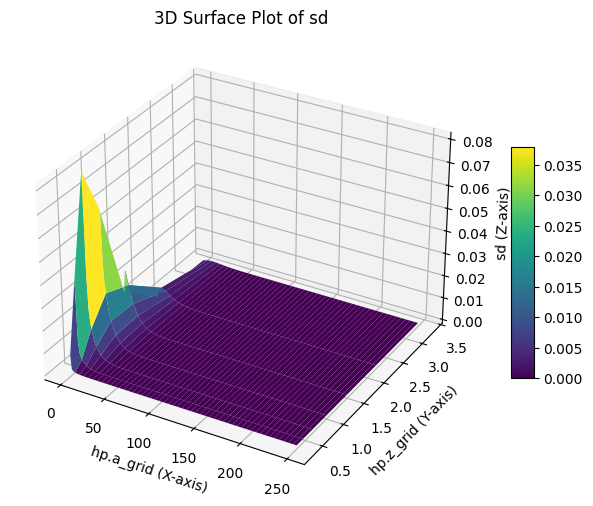

In [ ]:
# 定常分布 sd のプロット
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# メッシュグリッドを作成
X, Y = np.meshgrid(hp.a_grid_sd, hp.z_grid)
Z = sd_ini.T  # データの形状を合わせるため転置（必要なら）

# 3Dプロット
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# 軸ラベル
ax.set_xlabel('hp.a_grid (X-axis)')
ax.set_ylabel('hp.z_grid (Y-axis)')
ax.set_zlabel('sd (Z-axis)')
ax.set_title('3D Surface Plot of sd')

plt.show()

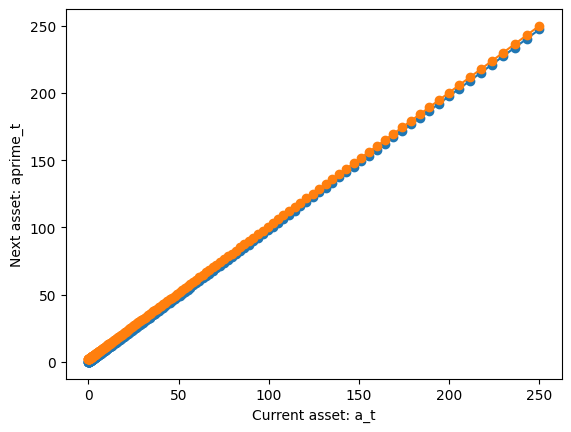

In [ ]:
# 来期の資産の政策関数をプロット
df = pd.DataFrame({
    'x_axis': hp.a_grid,
    'y_axis': aprime_ini[:,0]})
df2 = pd.DataFrame({
    'x_axis': hp.a_grid,
    'y_axis': aprime_ini[:,-1]})
# plot
plt.plot('x_axis', 'y_axis', data=df, linestyle='-', marker='o')  # 最も生産性が低い場合（青色）
plt.plot('x_axis', 'y_axis', data=df2, linestyle='-', marker='o')  # 最も生産性が高い場合（オレンジ色）
plt.xlabel('Current asset: a_t')
plt.ylabel('Next asset: aprime_t')
# plt.legend([""])
plt.show()

In [ ]:
np.max(np.abs(aprime_ini[:,-1]))

np.float64(249.8542328908701)

In [ ]:
# # 最終定常状態におけるvalue functionを求める

# # 価値関数評価用の初期化
# v_old = np.zeros((hp.na, hp.nz))
# v_new = np.empty_like(v_old)

# max_iter = 5000
# tol      = 1e-6

# for it in range(max_iter):
#     # 1ステップのBellman更新
#     for ia in range(hp.na):
#         a = hp.a_grid[ia]
#         for iz in range(hp.nz):
#             z = hp.z_grid[iz]
#             # 次期資産 a'
#             R_net = 1.0 + r_ini - 0 - delta
#             aprime = R_net * a \
#                    + w_ini * z \
#                    + 0 * k_ini \
#                    - c_ini[ia, iz]
#             # 期待値 E[V(a',z')]
#             ev = 0.0
#             for jz in range(hp.nz):
#                 # aprime を a_grid 上でスカラー補間
#                 v_at = interp_scalar(aprime, hp.a_grid, v_old[:, jz])
#                 ev  += hp.Pz[iz, jz] * v_at
#             # Bellman 更新
#             v_new[ia, iz] = hp.utility(c_ini[ia, iz]) + beta * ev

#     # 収束判定
#     diff = np.max(np.abs(v_new - v_old))
#     if diff < tol:
#         print(f"Terminal V converged in {it} iters, diff={diff:.2e}")
#         break

#     # in-place アップデート
#     v_old[:] = v_new

# else:
#     # 5000 回回しても収束しなかった場合
#     raise RuntimeError(f"Terminal VF did not converge (diff={diff:.2e})")

# # 最終的な定常価値関数
# value_function = v_new.copy()

# # UpdatePF を生成
# UpdatePF = BackwardInduction(hp)
# tau_ini = 0
# # 価値関数反復 (t → t-1)
# #opt_c, v_fin = maximize_u_value(value_function, r_ini, tau_ini, w_ini, xi_ini, beta, delta, b)
# opt_c, v_fin = UpdatePF(value_function, r_ini, tau_ini, w_ini, xi_ini)


# print("sup‐norm difference:", np.max(np.abs(v_fin - v_new)))

## 最終定常状態(fin)実行

In [ ]:
import time

start_time = time.time()  # 計測開始

# 税率を設定
tau = 0.005

# 資本ストックと所得移転のguess
K0d = 6.0* Lbar
Xi0 = tau * K0d

# ループの初期化
diff_KL = 1
diff_rev = 1
loop = 0




while abs(diff_KL) > 1e-8 or abs(diff_tax) > 1e-6:
    loop += 1
    # print("loop: ", loop)

    # 1 実質金利と賃金を更新
    r0 = alpha*(K0d/Lbar)**(alpha-1)
    w0 = (1 - alpha) * (K0d/Lbar) ** alpha


    # 2 消費の政策関数 hfun_c を求める
    hp = Setting(beta=beta, gamma = gamma, b = b, a_max = 250, lambdaPF = 1, na = 200, na_sd = 200, nz = 7, rho = rho, sigma = sigma, R = 1 + r0, w = w0, Xi = Xi0, tau=tau, delta = delta)
    hfun_c = SolveProblem(hp,EGMIterationWithGov)

    # 3
    # hfun_c から 次期のアセット aprime の政策関数を求める
    hfun_aprime = np.empty((len(hp.a_grid), len(hp.z_grid)))
    a_mesh, z_mesh = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij') # ユニバーサル関数を使用するためのグリッドを生成
    R_net = 1.0 + r0 - tau - delta
    hfun_aprime = R_net * a_mesh + hp.w * z_mesh + hp.Xi - hfun_c



    # 初期の定常分布を定義
    sd_grid = np.full((hp.na_sd, hp.nz), 1 / (hp.na_sd * hp.nz))

    # 4 状態分布を更新する
    sd = solve_sd(sd_grid, hp.na, hp.nz, hp.na_sd, hp.a_grid, hp.a_grid_sd, hp.Pz, hfun_aprime, critmu = 1e-8)

    # 5 更新された状態分布から資本ストックの総供給を求める
    Amesh, _ = np.meshgrid(hp.a_grid_sd, hp.z_grid, indexing='ij')
    K0s = np.sum(Amesh * sd)
    # # --- hfun_aprime を補間 ---
    # hfun_aprime_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
    # for iz in range(len(hp.z_grid)):
    #     interpolate_y(hp.a_grid, a_grid_sd, hfun_aprime[:, iz], hfun_aprime_interp[:, iz])
    # # 総資本ストック供給 K_s の計算
    # K0s = np.sum(hfun_aprime_interp * sd)

    # 6 資本ストックを更新
    print("K0s: ", K0s)
    diff_KL = (K0s/Lbar - K0d/Lbar)
    print("diff_KL: ", diff_KL)

    KdL = 0.95*K0d/Lbar + (1-0.95)*K0s/Lbar
    K0d = KdL * Lbar

    # 7 税収を計算して所得移転を更新
    tax = tau * K0s

    diff_tax = tax - Xi0
    print("diff_tax: ", diff_tax)
    Xi0 = 0.5*Xi0 + (1-0.5)*tax

end_time = time.time()  # 計測終了

print("Elapsed time:", end_time - start_time, "seconds")

PF Error at iteration 25 is 0.33894779767993555.
PF Error at iteration 50 is 0.06631000045121027.
PF Error at iteration 75 is 0.01852934293063413.
PF Error at iteration 100 is 0.005519649555878914.
PF Error at iteration 125 is 0.0015745125052717412.
PF Error at iteration 150 is 0.0003855676157513699.
PF Error at iteration 175 is 6.84505613719466e-05.
PF Error at iteration 200 is 9.25797041873011e-06.
PF Error at iteration 225 is 1.1566344539915008e-06.
PF Error at iteration 250 is 1.4339042309075012e-07.
PF Error at iteration 275 is 1.779619651642861e-08.

Converged in 282 iterations.
K0s:  3.8705490965959113
diff_KL:  -2.5301879079020724
diff_tax:  -0.014112027195148577
PF Error at iteration 25 is 0.3403174556838735.
PF Error at iteration 50 is 0.06718027828998174.
PF Error at iteration 75 is 0.01913280454587607.
PF Error at iteration 100 is 0.005908899759788255.
PF Error at iteration 125 is 0.0018093234110381218.
PF Error at iteration 150 is 0.000519048790351917.
PF Error at iteratio

In [ ]:
sd_fin = sd
k_fin = K0d

w = (1 - alpha) * (K0d/Lbar) ** alpha
w_fin = w
r_fin = r0

xi_fin = tau * k_fin

aprime_fin = hfun_aprime

c_fin = hfun_c

print(r_fin-delta)
print(k_fin/Lbar)

0.03865296828610762
5.66450981478309


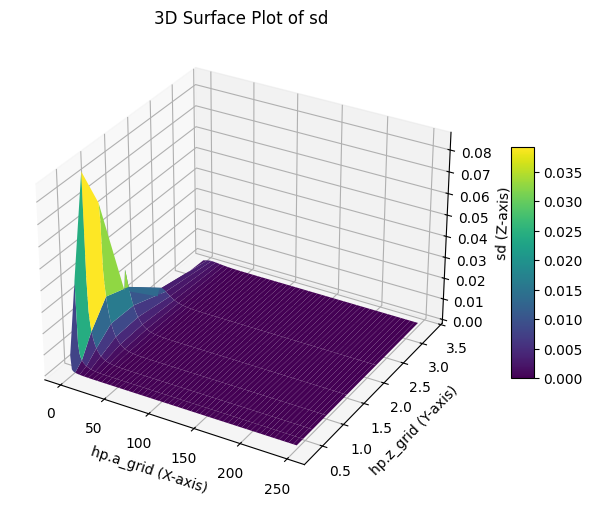

In [ ]:
# 定常分布 sd のプロット
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# メッシュグリッドを作成
X, Y = np.meshgrid(hp.a_grid_sd, hp.z_grid)
Z = sd_fin.T  # データの形状を合わせるため転置（必要なら）

# 3Dプロット
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# 軸ラベル
ax.set_xlabel('hp.a_grid (X-axis)')
ax.set_ylabel('hp.z_grid (Y-axis)')
ax.set_zlabel('sd (Z-axis)')
ax.set_title('3D Surface Plot of sd')

plt.show()

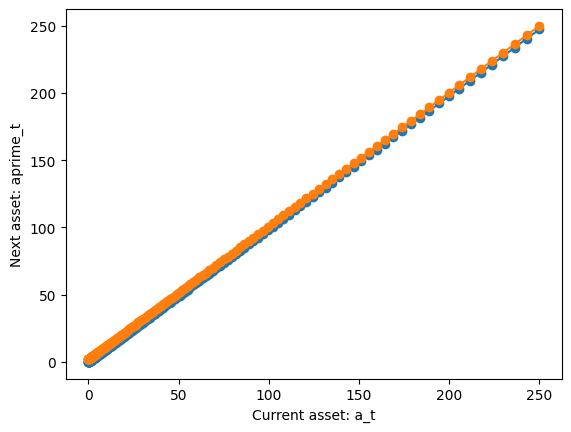

In [ ]:
# 来期の資産の政策関数をプロット
df = pd.DataFrame({
    'x_axis': hp.a_grid,
    'y_axis': aprime_fin[:,0]})
df2 = pd.DataFrame({
    'x_axis': hp.a_grid,
    'y_axis': aprime_fin[:,-1]})
# plot
plt.plot('x_axis', 'y_axis', data=df, linestyle='-', marker='o')  # 最も生産性が低い場合（青色）
plt.plot('x_axis', 'y_axis', data=df2, linestyle='-', marker='o')  # 最も生産性が高い場合（オレンジ色）
plt.xlabel('Current asset: a_t')
plt.ylabel('Next asset: aprime_t')
# plt.legend([""])
plt.show()

In [ ]:
np.max(np.abs(aprime_fin[:,-1]))

np.float64(249.7760164389177)

## 移行過程

### 収束するまで繰り返し

### 4-a政策関数と価値関数の導出

In [ ]:
# from scipy.optimize import fminbound
# import numpy as np

# def maximization_problem(
#     c: float,
#     i_a: int,
#     i_z: int,
#     vfun_next: np.ndarray,
#     r: float,
#     tau: float,
#     w: float,
#     xi: float,
#     beta: float,
#     delta: float,
#     b: float,
# ) -> float:
#     """
#     Args:
#       c           : 今期の消費
#       i_a, i_z    : 今期の資産・ショックのインデックス
#       vfun_next   : 次期の価値関数配列 (shape=(na,nz))
#       t           : 現在期番号（1 から T-1 を想定）
#       r           : 金利パス配列 (長さ=T)
#       tau         : 資本税率パス配列 (長さ=T)
#       w           : 賃金パス配列 (長さ=T)
#       xi          : 政府移転パス配列 (長さ=T)
#       beta        : 割引因子
#       delta       : 減耗率
#       b           : 借入制約パラメータ

#     Returns:
#       今期の効用＋割引期待効用
#     """
#     # aprime のベクトル計算
#     R_net = 1.0 + r - tau - delta
#     aprime = R_net * hp.a_grid + w * hp.z_grid[i_z] + xi - c

#     # 期待値の計算
#     expectation = 0.0
#     for j_z in range(len(hp.z_grid)):
#         # vfun_next[:, j_z] を aprime 上で補間
#         vf_interp = np.empty(len(hp.a_grid), dtype=np.float64)
#         interpolate_y(hp.a_grid, aprime, vfun_next[:, j_z], vf_interp)
#         expectation += hp.Pz[i_z, j_z] * vf_interp[i_a]

#     return hp.utility(c) + beta * expectation


# def maximize_u_value(
#     vfun_next: np.ndarray,
#     r: float,
#     tau: float,
#     w: float,
#     xi: float,
#     beta: float,
#     delta: float,
#     b: float,
# ) -> tuple[np.ndarray, np.ndarray]:
#     """
#     今期 t の vfun_next から
#       - 最適消費関数 optimal_c[i_a,i_z]
#       - 価値関数 v_value[i_a,i_z]
#     を返す。
#     """

#     optimal_c = np.zeros((hp.na, hp.nz))
#     v_value   = np.zeros((hp.na, hp.nz))

#     for i_a in range(hp.na):
#         for i_z in range(hp.nz):
#             # 目的関数（fminbound は最小化なので符号反転）
#             def objective(c):
#                 return -maximization_problem(
#                     c, i_a, i_z, vfun_next,
#                     r, tau, w, xi,
#                     beta, delta, b
#                 )

#             c_min = 1e-8
#             R_net = 1.0 + r - tau - delta
#             c_max = R_net * hp.a_grid[i_a] + w * hp.z_grid[i_z] + b + xi

#             sol = fminbound(objective, c_min, c_max, xtol=1e-5, full_output=True)
#             c_star, fval = sol[0], sol[1]

#             optimal_c[i_a, i_z] = c_star
#             v_value[i_a, i_z]   = -fval

#     return optimal_c, v_value


In [ ]:
# from numba import njit
# from quantecon.optimize import brent_max
# import numpy as np

# def BackwardInduction(hp):
#     # ── hp から必要なものをローカルに取り出す ──
#     a_grid, z_grid, Pz = hp.a_grid, hp.z_grid, hp.Pz
#     beta, delta, b    = hp.beta, hp.delta, hp.b
#     utility          = hp.utility   # 事前に @njit で jitted しておくか、Numba対応済みの関数を格納

#     # ── Bellman RHS ──
#     @njit
#     def bellman_rhs(c, ia, iz, vnext, r, tau, w, xi):
#         R_net = 1.0 + r - tau - delta

#         # 次期資産 aprime の計算
#         aprime = R_net * a_grid + w * z_grid[iz] + xi - c

#         # 期待価値
#         ev = 0.0
#         for jz in range(Pz.shape[1]):
#             yq = np.empty_like(a_grid)
#             interpolate_y(a_grid, aprime, vnext[:, jz], yq)
#             ev += Pz[iz, jz] * yq[ia]

#         return utility(c) + beta * ev

#     # ── 政策関数更新ルーチン ──
#     @njit
#     def UpdatePolicy(vnext, r, tau, w, xi):
#         na = a_grid.shape[0]
#         nz = z_grid.shape[0]
#         opt_c = np.empty((na, nz))
#         vval  = np.empty((na, nz))

#         for ia in range(na):
#             for iz in range(nz):
#                 R_net = 1.0 + r - tau - delta
#                 cmin  = 1e-12
#                 cmax  = R_net * a_grid[ia] + w * z_grid[iz] + xi + b

#                 # Brent法で最大化
#                 c_star, v_star, info = brent_max(
#                     bellman_rhs,
#                     cmin, cmax,
#                     args=(ia, iz, vnext, r, tau, w, xi),
#                     xtol=1e-6
#                 )

#                 opt_c[ia, iz] = c_star
#                 vval[ia, iz]  = v_star

#         return opt_c, vval

#     return UpdatePolicy

In [ ]:
from numba import njit
from quantecon.optimize import brent_max
import numpy as np

def BackwardInduction(hp):
    # ── hp から必要なものをローカルに取り出す ──
    a_grid, z_grid, Pz = hp.a_grid, hp.z_grid, hp.Pz
    beta, delta, b     = hp.beta,   hp.delta,  hp.b
    utility            = hp.utility  # 事前に @njit で jitted しておくこと

    # ── Bellman RHS ──
    @njit
    def bellman_rhs(c, ia, iz, vnext, r, tau, w, xi):
        # 1-period net return
        R_net = 1.0 + r - tau - delta

        # ここで「ベクトル」ではなく「スカラー」を計算
        apr = R_net * a_grid[ia] + w * z_grid[iz] + xi - c

        # 期待値の計算
        ev = 0.0
        for jz in range(Pz.shape[1]):
            # スカラー補間だけ
            v_at = interp_scalar(apr, a_grid, vnext[:, jz])
            ev  += Pz[iz, jz] * v_at

        return utility(c) + beta * ev

    # ── 政策関数更新ルーチン ──
    @njit
    def UpdatePolicy(vnext, r, tau, w, xi):
        na = a_grid.shape[0]
        nz = z_grid.shape[0]
        opt_c = np.empty((na, nz))
        vval  = np.empty((na, nz))

        for ia in range(na):
            for iz in range(nz):
                R_net = 1.0 + r - tau - delta
                cmin  = 1e-12
                cmax  = R_net * a_grid[ia] + w * z_grid[iz] + xi + b

                # Brent 法で最大化
                c_star, v_star, _ = brent_max(
                    bellman_rhs,
                    cmin, cmax,
                    args=(ia, iz, vnext, r, tau, w, xi),
                    xtol=1e-8
                )

                opt_c[ia, iz] = c_star
                vval[ia, iz]  = v_star

        return opt_c, vval

    return UpdatePolicy


### 4-b

In [ ]:
from numba import njit
import numpy as np

@njit
def sd_calculation(sd_old: np.ndarray,
                   pfgrid: np.ndarray,
                   agrid: np.ndarray,
                   agrid_sd: np.ndarray,
                   Pz: np.ndarray) -> np.ndarray:
    """
    solve_sd() のロジックを用いて、1回だけ次期の定常分布を計算する関数。

    Parameters:
    - sd_old: np.ndarray, 現在の分布 (na, nz)
    - pfgrid: np.ndarray, 政策関数 (na, nz)
    - agrid: np.ndarray, 資産グリッド (na,)
    - Pz: np.ndarray, 所得ショックの遷移行列 (nz, nz)

    Returns:
    - sd_next: np.ndarray, 次期の分布 (na, nz)

    """

    na, nz = pfgrid.shape # Use the shape of the input pfgrid (hfun_aprime_list[t-1])
    na_sd = sd_old.shape[0] # Use the shape of the input sd_old

    # -1. 政策関数の行列を補間して、行数を na 個から na_sd 個に変える
    # pfgrid -> pfgrid_interp
    pfgrid_interp = np.empty((na_sd,nz))              # 空の箱を用意
    for z_index in range(nz):
      aprime_new = np.empty(na_sd)
      interpolate_y(agrid, agrid_sd, pfgrid[:, z_index], aprime_new)
      pfgrid_interp[:,z_index] = aprime_new


    # 0. transition matrixを計算
    G = np.zeros((na_sd*nz,na_sd*nz))
    weight = np.zeros((na_sd,nz))

    for iz in range(nz):
      for ia in range(na_sd):

        # 政策関数 pfgrid[ia, iz] に合わせる
        aprime = pfgrid_interp[ia, iz]


        if aprime < agrid_sd[0]:
            weight[ia, iz] = 1.0
            jtilde = 0
        elif aprime > agrid_sd[-1]:
            weight[ia, iz] = 0
            jtilde = na_sd - 2
        else:
          # aprimeが落ちる区間の左端のグリッドのインデックスを探す
          jtilde = gridlookup2(aprime, agrid_sd)
          # 重み weight[ia, iz] に格納
          weight[ia, iz] = (agrid_sd[jtilde+1] - aprime) / (agrid_sd[jtilde+1] - agrid_sd[jtilde])

        # スタックしたときの現在の状態のインデックスを計算
        i_s = iz * na_sd + ia

        # 次期外生状態 jz でループ
        for jz in range(nz):

            # スタックしたときの次期の状態のインデックスを計算
            j_s  = jz * na_sd + jtilde

            # 遷移確率行列 G に代入
            #   - Pe[iz, jz] : 現在 iz から次期 jz への外生ショックの遷移確率
            G[i_s, j_s ] += weight[ia, iz]   * Pz[iz, jz]
            G[i_s, j_s + 1] += (1.0 - weight[ia, iz]) * Pz[iz, jz]


    # sd_old をベクトル化して更新
    mu_old = sd_old.T.flatten()  # shape = (na * nz,)
    mu_new = G.T @ mu_old
    mu_new = mu_new / np.sum(mu_new)  # 正規化

    # 2次元 (na, nz) に戻して返す
    sd_next = mu_new.reshape(nz, na_sd).T
    return sd_next

### 4-c

In [ ]:
# import numpy as np

# def compute_K_path(sd_list: list,
#                    agrid_sd: np.ndarray,
#                    T: int) -> np.ndarray:
#     """
#     分布リスト sd_list をもとに、各期の総資本 K_t を計算し、
#     NumPy 配列で返す関数

#     Parameters
#     ----------
#     sd_list : list of ndarray
#         各期の分布（shape: (na_sd, nz)）のリスト。
#         len(sd_list) >= T を想定。
#     agrid_sd : ndarray
#         資産グリッド（shape: (na_sd,)）
#     T : int
#         計算する期間数

#     Returns
#     -------
#     K_path : ndarray
#         各期の総資本 K_t の配列 (shape: (T,))
#     """
#     # 出力用の配列をあらかじめ確保
#     K_path = np.empty(T, dtype=float)

#     for t in range(T):
#         mu = sd_list[t]
#         # 資産×分布の要素積を計算して格納
#         K_path[t] = np.sum(mu * agrid_sd[:, np.newaxis])

#     return K_path


### 4-d

In [ ]:
def compute_error(path_new: list, path_old: list) -> float:
    """
    新しく求めた K_path と当初の予測 K_path_old との最大誤差を返す関数

    Parameters
    ----------
    K_path_new : list of float
        新しく計算された各期の総資本（K_path）
    K_path_old : list of float
        当て推量された各期の総資本

    Returns
    -------
    max_error : float
        各期の誤差の絶対値の最大値
    """
    path_new = np.array(path_new)
    path_old = np.array(path_old)

    error = (path_new - path_old)
    max_abs_error = np.max(np.abs(error))

    return max_abs_error, error

## 実行

In [ ]:

T = 200

# 変化後の税率
tau_fin = 0.005

# 税率パス
#  = np.zeros(T+2)
# tau_path[1:] = 0.005
tau_path_iter= tau_fin * np.ones(T)
tau_path= np.append(0, tau_fin * np.ones(T))

# 初期資本ストックパスの当て推量
#K_list = np.linspace(k_ini, k_fin, T)
K_list = k_fin * np.ones(T)
KL_list = K_list/Lbar

# 初期税収パス（教科書の手置き）
xi_old_iter= tau_path_iter * K_list
xi_old= np.append(xi_ini, xi_old_iter)

KL_max_abs_error = np.inf
xi_max_abs_error = np.inf
loop = 0


# UpdatePF を生成
hp_t = Setting(beta=beta, gamma = gamma, b = b, a_max = 250, lambdaPF = 1, na = 200, na_sd = 200, nz = 7, rho = rho, sigma = sigma, R = 1 + r_fin, w = w_fin, Xi = xi_fin, tau=tau_fin, delta = delta)
UpdatePF = BackwardInduction(hp_t)


# 政策関数・次期資産関数の箱
hfun_c      = np.empty((T+1, hp_t.na, hp_t.nz))
hfun_aprime_list = np.empty((T+1, hp_t.na, hp_t.nz))
#hfun_aprime_list[0] = aprime_ini

# 状態分布の箱
#sd_list = np.empty((T+1, hp_t.na_sd, hp_t.nz))
# sd_list[0] = sd_ini.copy()
# sd_list[-1] = sd_fin.copy()


# K_passの初期化
K_pass = np.empty(T)
KL_pass = np.empty(T)
#K_pass[0] = k_ini # Set the initial capital stock




# 最終定常状態におけるvalue functionを求める

# 価値関数評価用の初期化
v_old = np.zeros((hp.na, hp.nz))
v_new = np.empty_like(v_old)

max_iter = 5000
tol      = 1e-6

for it in range(max_iter):
    # 1ステップのBellman更新
    for ia in range(hp.na):
        a = hp.a_grid[ia]
        for iz in range(hp.nz):
            z = hp.z_grid[iz]
            # 次期資産 a'
            R_net = 1.0 + r_fin - tau_fin - delta
            aprime = R_net * a \
                   + w_fin * z \
                   + tau_fin * k_fin \
                   - c_fin[ia, iz]
            # 期待値 E[V(a',z')]
            ev = 0.0
            for jz in range(hp.nz):
                # aprime を a_grid 上でスカラー補間
                v_at = interp_scalar(aprime, hp.a_grid, v_old[:, jz])
                ev  += hp.Pz[iz, jz] * v_at
            # Bellman 更新
            v_new[ia, iz] = hp.utility(c_fin[ia, iz]) + beta * ev

    # 収束判定
    diff = np.max(np.abs(v_new - v_old))
    if diff < tol:
        print(f"Terminal V converged in {it} iters, diff={diff:.2e}")
        break

    # in-place アップデート
    v_old[:] = v_new

else:
    # 5000 回回しても収束しなかった場合
    raise RuntimeError(f"Terminal VF did not converge (diff={diff:.2e})")

# 最終的な定常価値関数
value_function = v_new.copy()

# 価値関数反復 (t → t-1)
opt_c, v_fin = UpdatePF(value_function, r_fin, tau_fin, w_fin, xi_fin)
value_function = v_fin.copy()

print("sup‐norm difference:", np.max(np.abs(v_fin - v_new)))

Terminal V converged in 320 iters, diff=9.63e-07
sup‐norm difference: 0.00017161201343629529


In [ ]:

T = 500

# 変化後の税率
tau_fin = 0.005

# 税率パス
#  = np.zeros(T+2)
# tau_path[1:] = 0.005
tau_path_iter= tau_fin * np.ones(T)
tau_path= np.append(0, tau_fin * np.ones(T))

# 初期資本ストックパスの当て推量
#K_list = np.linspace(k_ini, k_fin, T)
K_list = k_fin * np.ones(T)
KL_list = K_list/Lbar

# 初期税収パス（教科書の手置き）
xi_old_iter= tau_path_iter * K_list
xi_old= np.append(xi_ini, xi_old_iter)

KL_max_abs_error = np.inf
xi_max_abs_error = np.inf
loop = 0


# UpdatePF を生成
hp_t = Setting(beta=beta, gamma = gamma, b = b, a_max = 250, lambdaPF = 1, na = 200, na_sd = 200, nz = 7, rho = rho, sigma = sigma, R = 1 + r_fin, w = w_fin, Xi = xi_fin, tau=tau_fin, delta = delta)
UpdatePF = BackwardInduction(hp_t)


# 政策関数・次期資産関数の箱
hfun_c      = np.empty((T+1, hp_t.na, hp_t.nz))
hfun_aprime_list = np.empty((T+1, hp_t.na, hp_t.nz))
#hfun_aprime_list[0] = aprime_ini

# 状態分布の箱
#sd_list = np.empty((T+1, hp_t.na_sd, hp_t.nz))
# sd_list[0] = sd_ini.copy()
# sd_list[-1] = sd_fin.copy()


# K_passの初期化
K_pass = np.empty(T)
KL_pass = np.empty(T)
#K_pass[0] = k_ini # Set the initial capital stock




# 最終定常状態におけるvalue functionを求める
v_old = np.zeros((hp.na, hp.nz))
v_new = np.empty_like(v_old)

max_iter = 5000
tol = 1e-6


for it in range(max_iter):
    # 各状態 (ia, iz) で1ステップ更新
    for ia in range(hp.na):
        for iz in range(hp.nz):
            aprime = (1 + r_fin - tau_fin - delta) * hp.a_grid[ia] \
                     + w_fin * hp.z_grid[iz] \
                     + tau_fin * k_fin \
                     - c_fin[ia, iz]

            # 期待値
            cont_val = 0.0
            for jz in range(hp.nz):
                cont_val += np.interp(aprime, hp.a_grid, v_old[:, jz]) * hp.Pz[iz, jz]

            v_new[ia, iz] = hp.utility(c_fin[ia, iz]) + beta * cont_val

    diff = np.max(np.abs(v_new - v_old))
    if diff < tol:
        break
    v_old[:] = v_new  # in-place update

if diff >= tol:
    raise RuntimeError("VF iteration failed to converge")
value_function = v_new.copy()

# 価値関数反復 (t → t-1)
opt_c, v_fin = UpdatePF(value_function, r_fin, tau_fin, w_fin, xi_fin)
value_function = v_fin.copy()






while (KL_max_abs_error > 1e-5) or (xi_max_abs_error > 1e-5):
    loop += 1

    # 金利・賃金パスを更新（t = 0期については初期ssの値を追加）
    r_path_iter = alpha * (KL_list)**(alpha-1)
    r_path = np.append(r_ini, r_path_iter)
    w_path_iter = (1 - alpha) * (KL_list)**alpha
    w_path = np.append(w_ini, w_path_iter)

    xi_old= np.append(xi_ini, xi_old_iter)


    # (1) バックワード・インダクション
    value_function = v_fin.copy()
    for t in range(T, -1, -1): # t=200から0まで
        # t 期 のパラメータをセット
        rt   = r_path[t]
        wt   = w_path[t]
        taut = tau_path[t]
        xit  = xi_old[t]

        # 価値関数反復 (t → t-1)
        opt_c, v_value = UpdatePF(value_function, rt, taut, wt, xit)
        hfun_c[t] = opt_c
        value_function = v_value.copy()

        # 予算制約式から次期資産 a' を計算
        R_net = 1 + rt - taut - delta
        for i_a in range(hp_t.na):
            for i_z in range(hp_t.nz):
                hfun_aprime_list[t, i_a, i_z] = R_net * hp_t.a_grid[i_a] + wt * hp_t.z_grid[i_z] + xit - hfun_c[t, i_a, i_z]


    # (2) フォワード分布計算

    # 初期分布を設定
    sd = sd_ini.copy()

    for t in range(1, T+1):  # t=1から200まで
        sd = sd_calculation(
            sd,
            hfun_aprime_list[t-1],
            hp_t.a_grid,
            hp_t.a_grid_sd,
            hp_t.Pz
        )
        K_pass[t-1] = np.sum(sd * hp_t.a_grid_sd[:, np.newaxis])
        Lsup = np.sum(sd * hp_t.z_grid[np.newaxis, :])
        KL_pass[t-1] = K_pass[t-1]/Lsup

    # 資本・税収のパスを集計
    #K_pass = compute_K_path(sd_list, hp_t.a_grid_sd, T)
    KL_max_abs_error, _ = compute_error(KL_pass, KL_list)

    xi_new = tau_path_iter * K_pass
    xi_max_abs_error, _ = compute_error(xi_new, xi_old_iter)

    # 平滑化 & 端点固定
    KL_list = 0.8*KL_list + 0.2*KL_pass
    #KL_list = KL_list + 0.05 * (KL_pass - KL_list)

    xi_old_iter = 0.8*xi_old_iter + 0.2*xi_new
    #xi_old_iter = xi_old_iter + 0.1 * (xi_new - xi_old_iter)

    print(f"loop {loop}: K_err={KL_max_abs_error:.2e}, xi_err={xi_max_abs_error:.2e}")


loop 1: K_err=3.78e-01, xi_err=2.11e-03
loop 2: K_err=2.89e-01, xi_err=1.61e-03
loop 3: K_err=2.26e-01, xi_err=1.26e-03
loop 4: K_err=1.76e-01, xi_err=9.84e-04
loop 5: K_err=1.39e-01, xi_err=7.73e-04
loop 6: K_err=1.09e-01, xi_err=6.07e-04
loop 7: K_err=8.58e-02, xi_err=4.79e-04
loop 8: K_err=6.76e-02, xi_err=3.77e-04
loop 9: K_err=5.34e-02, xi_err=2.98e-04
loop 10: K_err=4.68e-02, xi_err=2.61e-04
loop 11: K_err=4.99e-02, xi_err=2.78e-04
loop 12: K_err=5.36e-02, xi_err=2.99e-04
loop 13: K_err=5.91e-02, xi_err=3.29e-04
loop 14: K_err=6.34e-02, xi_err=3.54e-04
loop 15: K_err=6.51e-02, xi_err=3.63e-04
loop 16: K_err=6.35e-02, xi_err=3.54e-04
loop 17: K_err=5.92e-02, xi_err=3.30e-04
loop 18: K_err=5.38e-02, xi_err=3.00e-04
loop 19: K_err=4.73e-02, xi_err=2.64e-04
loop 20: K_err=4.11e-02, xi_err=2.29e-04
loop 21: K_err=3.48e-02, xi_err=1.94e-04
loop 22: K_err=2.93e-02, xi_err=1.63e-04
loop 23: K_err=2.42e-02, xi_err=1.35e-04
loop 24: K_err=2.00e-02, xi_err=1.11e-04
loop 25: K_err=1.63e-02, 

In [ ]:
KL_list

array([6.00989778, 5.97119637, 5.93686355, 5.90636215, 5.87926675,
       5.85518871, 5.83379014, 5.81478084, 5.7978861 , 5.78286916,
       5.7695137 , 5.75760659, 5.74698917, 5.7375256 , 5.72907566,
       5.72152172, 5.71477048, 5.70873556, 5.70333867, 5.69851835,
       5.6942143 , 5.6903725 , 5.68694298, 5.68388467, 5.68115965,
       5.67873265, 5.6765712 , 5.67464756, 5.67293822, 5.67142004,
       5.67007238, 5.66887679, 5.6678168 , 5.66687769, 5.66604662,
       5.66531143, 5.6646616 , 5.66408775, 5.66358149, 5.66313533,
       5.66274251, 5.66239704, 5.66209363, 5.66182752, 5.6615945 ,
       5.6613908 , 5.66121305, 5.66105828, 5.66092382, 5.6608073 ,
       5.66070663, 5.66061991, 5.6605455 , 5.66048191, 5.66042784,
       5.66038211, 5.6603437 , 5.6603117 , 5.6602853 , 5.66026377,
       5.66024648, 5.66023289, 5.66022249, 5.66021484, 5.66020957,
       5.66020634, 5.66020484, 5.66020483, 5.66020607, 5.66020835,
       5.66021151, 5.66021539, 5.66021986, 5.6602248 , 5.66023

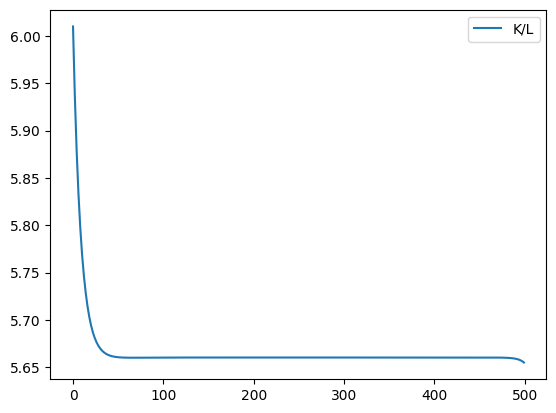

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# データ生成
x = np.arange(T)
y = KL_list

# プロット
plt.plot(x, y, label="K/L")

# 凡例の表示
plt.legend()

# プロット表示(設定の反映)
plt.show()

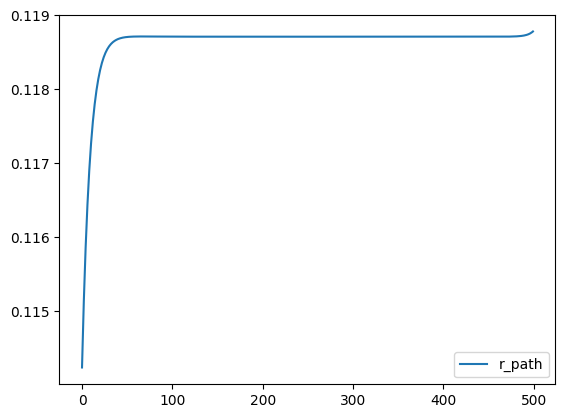

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# データ生成
x = np.arange(T)
y = r_path_iter

# プロット
plt.plot(x, y, label="r_path")

# 凡例の表示
plt.legend()

# プロット表示(設定の反映)
plt.show()

# アーカイブ

### 最終定常状態の資本ストックもエラー計算に入れるがiterationには入れないver（収束しない）

In [ ]:

T = 200


# 最終定常状態におけるvalue functionを求める
v_old = np.zeros((hp.na, hp.nz))
v_new = np.empty_like(v_old)

max_iter = 5000
tol = 1e-6

tau_fin = 0.005

for it in range(max_iter):
    # 各状態 (ia, iz) で1ステップ更新
    for ia in range(hp.na):
        for iz in range(hp.nz):
            aprime = (1 + r_fin - tau_fin - delta) * hp.a_grid[ia] \
                     + w_fin * hp.z_grid[iz] \
                     + tau_fin * k_fin \
                     - c_fin[ia, iz]

            # 期待値
            cont_val = 0.0
            for jz in range(hp.nz):
                cont_val += np.interp(aprime, hp.a_grid, v_old[:, jz]) * hp.Pz[iz, jz]

            v_new[ia, iz] = hp.utility(c_fin[ia, iz]) + beta * cont_val

    diff = np.max(np.abs(v_new - v_old))
    if diff < tol:
        break
    v_old[:] = v_new  # in-place update

if diff >= tol:
    raise RuntimeError("VF iteration failed to converge")
value_function = v_new.copy()



# 税率パス
#  = np.zeros(T+2)
# tau_path[1:] = 0.005
tau_path_iter= tau_fin * np.ones(T)
tau_path= np.append(0, tau_fin * np.ones(T))

# 初期資本ストックパスの当て推量
#K_list = np.linspace(k_ini, k_fin, T)
K_list = k_fin * np.ones(T)

# 初期税収パス（教科書の手置き）
xi_old_iter= tau_path_iter * K_list
#xi_old= np.append(xi_ini, xi_old_iter)

K_max_abs_error = np.inf
xi_max_abs_error = np.inf
loop = 0


# UpdatePF を生成
hp_t = Setting(beta=beta, gamma = gamma, b = b, a_max = 45, lambdaPF = 1, na = 50, na_sd = 50, nz = 7, rho = rho, sigma = sigma, R = 1 + r_fin, w = w_fin, Xi = xi_fin, tau=tau_fin, delta = delta)
UpdatePF = BackwardInduction(hp_t)


# 政策関数・次期資産関数の箱
hfun_c      = np.empty((T+1, hp_t.na, hp_t.nz))
hfun_aprime_list = np.empty((T+1, hp_t.na, hp_t.nz))
#hfun_aprime_list[0] = aprime_ini

# 状態分布の箱
#sd_list = np.empty((T+1, hp_t.na_sd, hp_t.nz))
# sd_list[0] = sd_ini.copy()
# sd_list[-1] = sd_fin.copy()


# K_passの初期化
K_pass = np.empty(T+1)
#K_pass[0] = k_ini # Set the initial capital stock



while (K_max_abs_error > 1e-5) or (xi_max_abs_error > 1e-5):
    loop += 1

    # 金利・賃金パスを更新（t = 0期については初期ssの値を追加）
    r_path_iter = alpha * (K_list / Lbar)**(alpha-1)
    r_path = np.append(r_ini, r_path_iter)
    w_path_iter = (1 - alpha) * (K_list / Lbar)**alpha
    w_path = np.append(w_ini, w_path_iter)

    xi_old= np.append(xi_ini, xi_old_iter)


    # (1) バックワード・インダクション
    value_function = v_new.copy()
    for t in range(T, -1, -1):
        # t 期 のパラメータをセット
        rt   = r_path[t]
        wt   = w_path[t]
        taut = tau_path[t]
        xit  = xi_old[t]

        # 価値関数反復 (t → t-1)
        opt_c, v_value = UpdatePF(value_function, rt, taut, wt, xit)
        hfun_c[t] = opt_c
        value_function = v_value

        # 予算制約式から次期資産 a' を計算
        R_net = 1 + rt - taut - delta
        for i_a in range(hp_t.na):
            for i_z in range(hp_t.nz):
                hfun_aprime_list[t, i_a, i_z] = R_net * hp_t.a_grid[i_a] + wt * hp_t.z_grid[i_z] + xit - hfun_c[t, i_a, i_z]


    # (2) フォワード分布計算

    # 初期分布を設定
    sd = sd_ini.copy()

    for t in range(1, T+2):
        sd = sd_calculation(
            sd,
            hfun_aprime_list[t-1],
            hp_t.a_grid,
            hp_t.a_grid_sd,
            hp_t.Pz
        )
        K_pass[t-1] = np.sum(sd * hp_t.a_grid_sd[:, np.newaxis])

    # 資本・税収のパスを集計
    #K_pass = compute_K_path(sd_list, hp_t.a_grid_sd, T)
    K_list_e = np.append(K_list, k_fin)
    K_max_abs_error, _ = compute_error(K_pass, K_list_e)

    xi_new = tau * K_pass
    xi_old_iter_e = np.append(xi_old_iter, xi_fin)
    xi_max_abs_error, _ = compute_error(xi_new, xi_old_iter_e)

    # 平滑化 & 端点固定
    K_list = 0.8*K_list + 0.2*K_pass[0:T]
    #K_list[0], K_list[-1] = k_ini, k_fin

    xi_old_iter = 0.8*xi_old_iter + 0.2*xi_new[0:T]
    #xi_old[0], xi_old[-1] = xi_ini, xi_fin

    print(f"loop {loop}: K_err={K_max_abs_error:.2e}, xi_err={xi_max_abs_error:.2e}")

loop 1: K_err=4.17e-01, xi_err=2.09e-03
loop 2: K_err=3.20e-01, xi_err=1.60e-03
loop 3: K_err=2.50e-01, xi_err=1.25e-03
loop 4: K_err=1.95e-01, xi_err=9.76e-04
loop 5: K_err=1.53e-01, xi_err=7.66e-04
loop 6: K_err=1.20e-01, xi_err=6.02e-04
loop 7: K_err=9.49e-02, xi_err=4.74e-04
loop 8: K_err=7.48e-02, xi_err=3.74e-04
loop 9: K_err=5.90e-02, xi_err=2.95e-04
loop 10: K_err=5.30e-02, xi_err=2.65e-04
loop 11: K_err=5.27e-02, xi_err=2.63e-04
loop 12: K_err=5.28e-02, xi_err=2.64e-04
loop 13: K_err=5.26e-02, xi_err=2.63e-04
loop 14: K_err=5.27e-02, xi_err=2.63e-04
loop 15: K_err=5.26e-02, xi_err=2.63e-04
loop 16: K_err=5.26e-02, xi_err=2.63e-04
loop 17: K_err=5.26e-02, xi_err=2.63e-04
loop 18: K_err=5.26e-02, xi_err=2.63e-04
loop 19: K_err=5.25e-02, xi_err=2.63e-04
loop 20: K_err=5.26e-02, xi_err=2.63e-04
loop 21: K_err=5.25e-02, xi_err=2.63e-04
loop 22: K_err=5.25e-02, xi_err=2.63e-04
loop 23: K_err=5.25e-02, xi_err=2.63e-04
loop 24: K_err=5.25e-02, xi_err=2.63e-04
loop 25: K_err=5.25e-02, 

SystemError: CPUDispatcher(<function BackwardInduction.<locals>.UpdatePolicy at 0x7ab5500f2de0>) returned a result with an exception set

### 最終定常状態の資本ストックもiterationとエラー計算に入れるver

In [ ]:

T = 200


# 最終定常状態におけるvalue functionを求める
v_old = np.zeros((hp.na, hp.nz))
v_new = np.empty_like(v_old)

max_iter = 5000
tol = 1e-6

tau_fin = 0.005

for it in range(max_iter):
    # 各状態 (ia, iz) で1ステップ更新
    for ia in range(hp.na):
        for iz in range(hp.nz):
            aprime = (1 + r_fin - tau_fin - delta) * hp.a_grid[ia] \
                     + w_fin * hp.z_grid[iz] \
                     + tau_fin * k_fin \
                     - c_fin[ia, iz]

            # 期待値
            cont_val = 0.0
            for jz in range(hp.nz):
                cont_val += np.interp(aprime, hp.a_grid, v_old[:, jz]) * hp.Pz[iz, jz]

            v_new[ia, iz] = hp.utility(c_fin[ia, iz]) + beta * cont_val

    diff = np.max(np.abs(v_new - v_old))
    if diff < tol:
        break
    v_old[:] = v_new  # in-place update

if diff >= tol:
    raise RuntimeError("VF iteration failed to converge")
value_function = v_new.copy()



# 税率パス
#  = np.zeros(T+2)
# tau_path[1:] = 0.005
tau_path_iter= tau_fin * np.ones(T)
tau_path= np.append(0, tau_fin * np.ones(T))

# 初期資本ストックパスの当て推量
#K_list = np.linspace(k_ini, k_fin, T)
K_list = k_fin * np.ones(T)
K_list_e = np.append(K_list, k_fin)

# 初期税収パス（教科書の手置き）
xi_old_iter = tau_path_iter * K_list
xi_old_iter_e = tau * K_list_e
#xi_old= np.append(xi_ini, xi_old_iter)

K_max_abs_error = np.inf
xi_max_abs_error = np.inf
loop = 0


# UpdatePF を生成
hp_t = Setting(beta=beta, gamma = gamma, b = b, a_max = 45, lambdaPF = 1, na = 50, na_sd = 50, nz = 7, rho = rho, sigma = sigma, R = 1 + r_fin, w = w_fin, Xi = xi_fin, tau=tau_fin, delta = delta)
UpdatePF = BackwardInduction(hp_t)


# 政策関数・次期資産関数の箱
hfun_c      = np.empty((T+1, hp_t.na, hp_t.nz))
hfun_aprime_list = np.empty((T+1, hp_t.na, hp_t.nz))
#hfun_aprime_list[0] = aprime_ini

# 状態分布の箱
#sd_list = np.empty((T+1, hp_t.na_sd, hp_t.nz))
# sd_list[0] = sd_ini.copy()
# sd_list[-1] = sd_fin.copy()


# K_passの初期化
K_pass = np.empty(T+1)
#K_pass[0] = k_ini # Set the initial capital stock



while (K_max_abs_error > 1e-6) or (xi_max_abs_error > 1e-5):
    loop += 1

    # 金利・賃金パスを更新（t = 0期については初期ssの値を追加）
    r_path_iter = alpha * (K_list / Lbar)**(alpha-1)
    r_path = np.append(r_ini, r_path_iter)
    w_path_iter = (1 - alpha) * (K_list / Lbar)**alpha
    w_path = np.append(w_ini, w_path_iter)

    xi_old= np.append(xi_ini, xi_old_iter)


    # (1) バックワード・インダクション
    value_function = v_new.copy()
    for t in range(T, -1, -1):  # t=200から0まで
        # t 期 のパラメータをセット
        rt   = r_path[t]
        wt   = w_path[t]
        taut = tau_path[t]
        xit  = xi_old[t]

        # 価値関数反復 (t → t-1)
        opt_c, v_value = UpdatePF(value_function, rt, taut, wt, xit)
        hfun_c[t] = opt_c
        value_function = v_value

        # 予算制約式から次期資産 a' を計算
        R_net = 1 + rt - taut - delta
        for i_a in range(hp_t.na):
            for i_z in range(hp_t.nz):
                hfun_aprime_list[t, i_a, i_z] = R_net * hp_t.a_grid[i_a] + wt * hp_t.z_grid[i_z] + xit - hfun_c[t, i_a, i_z]


    # (2) フォワード分布計算

    # 初期分布を設定
    sd = sd_ini.copy()

    for t in range(1, T+2):  # t=1から201まで
        sd = sd_calculation(
            sd,
            hfun_aprime_list[t-1],
            hp_t.a_grid,
            hp_t.a_grid_sd,
            hp_t.Pz
        )
        K_pass[t-1] = np.sum(sd * hp_t.a_grid_sd[:, np.newaxis])

    # 資本・税収のパスを集計
    #K_pass = compute_K_path(sd_list, hp_t.a_grid_sd, T)
    K_max_abs_error, _ = compute_error(K_pass, K_list_e)

    xi_new = tau * K_pass
    #xi_old_iter_e = np.append(xi_old_iter, xi_fin)
    xi_max_abs_error, _ = compute_error(xi_new, xi_old_iter_e)

    # 平滑化 & 端点固定
    K_list_e = 0.8*K_list_e + 0.2*K_pass
    K_list = K_list_e[0:T]
    #K_list[0], K_list[-1] = k_ini, k_fin

    xi_old_iter_e = 0.8*xi_old_iter_e + 0.2*xi_new
    xi_old_iter = xi_old_iter_e[0:T]
    #xi_old[0], xi_old[-1] = xi_ini, xi_fin

    print(f"loop {loop}: K_err={K_max_abs_error:.2e}, xi_err={xi_max_abs_error:.2e}")

loop 1: K_err=4.17e-01, xi_err=2.09e-03
loop 2: K_err=3.20e-01, xi_err=1.60e-03
loop 3: K_err=2.50e-01, xi_err=1.25e-03
loop 4: K_err=1.95e-01, xi_err=9.76e-04
loop 5: K_err=1.53e-01, xi_err=7.66e-04
loop 6: K_err=1.20e-01, xi_err=6.02e-04
loop 7: K_err=9.49e-02, xi_err=4.74e-04
loop 8: K_err=7.48e-02, xi_err=3.74e-04
loop 9: K_err=5.90e-02, xi_err=2.95e-04
loop 10: K_err=4.66e-02, xi_err=2.33e-04
loop 11: K_err=3.68e-02, xi_err=1.84e-04
loop 12: K_err=2.91e-02, xi_err=1.46e-04
loop 13: K_err=2.30e-02, xi_err=1.15e-04
loop 14: K_err=1.82e-02, xi_err=9.12e-05
loop 15: K_err=1.44e-02, xi_err=7.22e-05
loop 16: K_err=1.14e-02, xi_err=5.72e-05
loop 17: K_err=9.06e-03, xi_err=4.53e-05
loop 18: K_err=7.18e-03, xi_err=3.59e-05
loop 19: K_err=5.69e-03, xi_err=2.85e-05
loop 20: K_err=4.51e-03, xi_err=2.26e-05
loop 21: K_err=3.58e-03, xi_err=1.79e-05
loop 22: K_err=2.84e-03, xi_err=1.42e-05
loop 23: K_err=2.25e-03, xi_err=1.13e-05
loop 24: K_err=1.79e-03, xi_err=8.94e-06
loop 25: K_err=1.42e-03, 

In [ ]:
K_list/Lbar

array([6.00153463, 5.96169843, 5.92640422, 5.89513073, 5.86738098,
       5.84276911, 5.82093585, 5.80152519, 5.78426623, 5.76891949,
       5.75527282, 5.74312862, 5.73233086, 5.72273265, 5.71420126,
       5.70661888, 5.69988103, 5.69389479, 5.68857217, 5.68383824,
       5.67962828, 5.67588465, 5.67255599, 5.66959682, 5.6669667 ,
       5.66463095, 5.66255858, 5.66072032, 5.65909012, 5.6576448 ,
       5.65636374, 5.65522861, 5.65422309, 5.65333269, 5.65254449,
       5.65184692, 5.65122977, 5.65068396, 5.65020148, 5.64977518,
       5.64939872, 5.64906647, 5.64877343, 5.64851513, 5.64828764,
       5.64808744, 5.64791142, 5.64775681, 5.64762116, 5.64750228,
       5.64739825, 5.64730734, 5.64722804, 5.64715899, 5.64709899,
       5.64704698, 5.64700201, 5.64696325, 5.64692997, 5.64690152,
       5.6468773 , 5.64685681, 5.64683958, 5.64682523, 5.64681338,
       5.64680373, 5.64679599, 5.64678994, 5.64678533, 5.64678198,
       5.64677972, 5.64677839, 5.64677786, 5.64677802, 5.64677

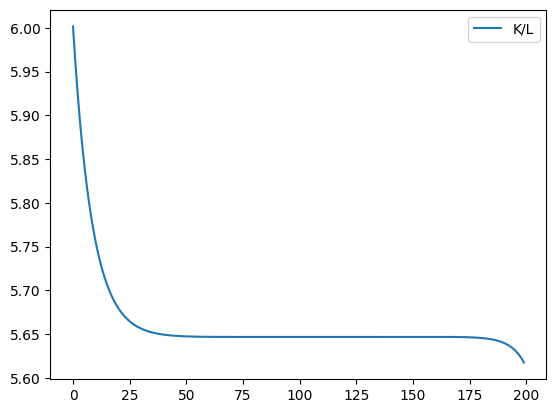

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# データ生成
x = np.arange(T)
y = K_list/Lbar

# プロット
plt.plot(x, y, label="K/L")

# 凡例の表示
plt.legend()

# プロット表示(設定の反映)
plt.show()

# テスト

In [ ]:
K_list

In [ ]:


T = 3
hfun_aprime = np.empty((T,len(hp.a_grid), len(hp.z_grid)))
hfun_c = np.empty((T,len(hp.a_grid), len(hp.z_grid)))
tmp = np.empty((T,len(hp.a_grid), len(hp.z_grid)))


for t in range(T-1,-1,-1):
    # t期の政策関数を求める
    hfun_c[t-1], value_function_list[t-1] = maximize_u_value(value_function_list[t])

    for i_a in range(len(hp.a_grid)):
        for i_z in range(len(hp.z_grid)):
          hfun_aprime[t-1, i_a, i_z] = (hp.a_grid[i_a] * (1 + (1 - tau[t-1]) * r[t-1]) + w[t-1] * hp.z_grid[i_z] + tau[t-1] * r[t-1] * K_list[t-1] - hfun_c[t-1, i_a, i_z])

In [ ]:
hfun_c[1][:,0]

In [ ]:
hfun_aprime[1][:,0]

In [ ]:
  # 政策関数をプロット
df = pd.DataFrame({
    'x_axis': hp.a_grid,
    'y_axis': hfun_aprime[2][:,0]
})

# plot
plt.plot('x_axis', 'y_axis', data=df, linestyle='-', marker='o')
plt.show()

In [ ]:
  # 政策関数をプロット
df = pd.DataFrame({
    'x_axis': hp.a_grid,
    'y_axis': hfun_c[2][:,0]
})

# plot
plt.plot('x_axis', 'y_axis', data=df, linestyle='-', marker='o')
plt.show()

In [ ]:
I = 3
for i in range(1,I):
  print(i)

# 4-b分布の計算(過去)

In [ ]:
@njit
def split_prob_to_agrid(aprime: float, agrid: np.ndarray) -> np.ndarray:
    """ 政策関数によって得られた a の値が、a_grid のどの点に移動するのかを示す確率ベクトルを計算する関数

    Args:
    aprime: 政策関数によって得られた a の値
    agrid: a のグリッド
    return: aprime が agrid のどの点に移動するのかを示す確率ベクトル
    """
    probs = np.zeros(len(agrid))
    # a の値が a_grid の最小値より小さい場合
    if aprime <= agrid[0]:
        probs[0] = 1.0
        return probs

    # a の値が a_grid の最大値より大きい場合
    if aprime >= agrid[-1]:
        probs[-1] = 1.0
        return probs

    # a の値が a_grid の最小値より大きく最大値より小さい場合
    for i in range(len(agrid)-1):
        if agrid[i] <= aprime <= agrid[i+1]:
            probs[i] = (agrid[i+1] - aprime) / (agrid[i+1] - agrid[i])
            probs[i+1] = (aprime - agrid[i]) / (agrid[i+1] - agrid[i])
            return probs

    # この行までに return されていない場合はエラーを出す
    raise ValueError("Splitting probability failed.")

@njit
def calc_weight_matrix(aprime_grid: np.ndarray, agrid: np.ndarray, split_prob_to_agrid = split_prob_to_agrid) -> np.ndarray:
    """ 前期の定常分布に係る重みづけ確率行列 weight_matrix を計算する関数

    Args:
        aprime_grid: 政策関数の行き先のグリッド
        agrid: 資産のグリッド
        split_prob: 政策関数によって得られた a の値が、a_grid のどの点に移動するのかを示す確率ベクトルを計算する関数

    Returns:
        weight_matrix: 前期の定常分布に係る重みづけ確率のグリッド、shape は aprime_grid と同じ
    """
    weight_matrix = np.empty((len(aprime_grid), len(aprime_grid[0]), len(agrid)))

    # aprime_grid は 二次元配列
    for i in range(len(aprime_grid)):
        for j in range(len(aprime_grid[0])):
            weight_matrix[i, j] = split_prob_to_agrid(float(aprime_grid[i, j]), agrid)
    return weight_matrix

@njit
def gen_pmesh(aprime_grid: np.ndarray, P: np.ndarray, next_y_index: int) -> np.ndarray:
    """ 遷移確率を 政策関数 aprime_grid との要素ごとの計算に使えるように meshgrid を生成する関数

    Args:
        aprime_grid (np.ndarray): 政策関数のグリッド
        P (np.ndarray): 遷移確率行列
        next_y_index (int): 次期の所得状態 y' のインデックス

    Returns:
        np.ndarray: 政策関数と遷移確率行列を使って計算するための meshgrid
    """
    pmesh = np.zeros(aprime_grid.shape)
    for i in range(len(aprime_grid)):
        for j in range(len(aprime_grid[0])):
            pmesh[i, j] = P[j, next_y_index]
    return pmesh

# def calc_sd_point(Pmesh, weight, sd_old) -> float:
#     """ 定常分布の一点を計算する関数

#     Args:
#         Pmesh (np.ndarray): 政策関数と遷移確率行列を使って計算した meshgrid
#         weight (np.ndarray): 前期の定常分布に係る重みづけ確率
#         sd_old (np.ndarray): 一期前の定常分布 f(a, y)

#     Returns:
#         float: 更新された(次期の)定常分布の一点の値
#     """
#     return np.sum(Pmesh * weight * sd_old)

@njit
def update_sd(aprime_grid: np.ndarray, agrid: np.ndarray, sd_old: np.ndarray, P: np.ndarray,
            split_prob_to_agrid = split_prob_to_agrid, calc_weight_matrix = calc_weight_matrix,
            gen_P = gen_pmesh,
            # calc_sd_point = calc_sd_point
            ) -> np.ndarray:
    """ 定常分布を更新する関数

    Args:
        aprime_grid (np.ndarray): 政策関数のグリッド
        agrid (np.ndarray): 資産のグリッド
        sd_old (np.ndarray): 更新前の定常分布
        P (np.ndarray): 遷移確率行列
        split_prob (Callable): 政策関数によって得られた a の値が、a_grid のどの点に移動するのかを示す確率ベクトルを計算する関数
        calc_weight (Callable): 前期の定常分布に係る重みづけ確率 weight を計算する関数
        gen_P (Callable): 遷移確率を 政策関数 aprime_grid との要素ごとの計算に使えるように meshgrid を生成する関数
        calc_sd_point (Callable): 定常分布の一点を計算する関数

    Returns:
        sd_new（np.ndarray）: 更新された定常分布のグリッド
    """
    sd_new = np.zeros(sd_old.shape)
    weight_matrix = calc_weight_matrix(aprime_grid, agrid, split_prob_to_agrid)
    for i in range(len(aprime_grid)):
        for j in range(len(aprime_grid[0])):
            p_mesh = gen_P(aprime_grid, P, j)
            # sd_new[i, j] = calc_sd_point(p_mesh, weight_matrix[:,:,i], sd_old)
            sd_new[i,j] = np.sum(p_mesh * weight_matrix[:,:,i] * sd_old)

    return sd_new

@njit
def sd_calculation(sd0: np.ndarray, aprime_grid: np.ndarray, agrid: np.ndarray, P: np.ndarray,

                        update_sd = update_sd) -> np.ndarray:
    """ 定常分布を計算する関数

    Args:
        aprime_grid (np.ndarray): 政策関数のグリッド
        agrid (np.ndarray): 資産のグリッド
        guess_sd (np.ndarray): 初期の定常分布のグリッド
        P (np.ndarray): 遷移確率行列
        tol (float, optional): 許容する誤差. Defaults to 1e-6.
        max_iter (int, optional): 最大の反復回数. Defaults to 1000.
        update_sd (_type_, optional): 定常分布を更新する関数. Defaults to update_sd.

    Returns:
        np.ndarray: 収束した定常分布のグリッド
    """
    sd_old = sd0
    sd_next = update_sd(aprime_grid, agrid, sd_old, P)
    return sd_next

# 正しい解があるかどうかのテスト

In [ ]:
K_list

array([7.20629651, 6.95864747, 6.71099843])

In [ ]:
T = 3

tau = np.zeros(T) # T期間分のtauを格納する箱を作る
tau[1:] = 0.1 # 初期状態以外のtauを0.1に設定

# K_list = np.linspace(k_ini, k_fin, T) # 資本ストックの初期値を当て推量、最初と最後の値は定常状態のものを用いる

K_test = np.linspace(k_ini, k_fin, 50) # 資本ストックの初期値を当て推量、最初と最後の値は定常状態のものを用いる



print(K_list)
max_abs_error = 1
loop = 0

# while max_abs_error > 1e-6: # 繰り返し計算前後で価値関数が等しくなるまで
for loop in range(len(K_test)):

      K_list = [k_ini,K_test[loop], k_fin]

      w = (1 - alpha) * (K_list/Lbar) ** alpha # 当て推量したKを基に賃金を計算
      r = alpha * (K_list / Lbar) ** (alpha - 1) - delta # 当て推量したKを基に金利を計算
      # print(f"r:{r}")
      xi = K_list * tau * r # 当て推量したK,rとtauより政府移転を計算

      hfun_aprime = np.empty((T,len(hp.a_grid), len(hp.z_grid)))
      hfun_c = np.empty((T,len(hp.a_grid), len(hp.z_grid)))

      for t in range(T-1,-1,-1):
          # t期の政策関数を求める
          hfun_c[t-1], value_function_list[t-1] = maximize_u_value(value_function_list[t])

          for i_a in range(len(hp.a_grid)):
              for i_z in range(len(hp.z_grid)):
                hfun_aprime[t-1, i_a, i_z] = (hp.a_grid[i_a] * (1 + (1 - tau[t-1]) * r[t-1]) + w[t-1] * hp.z_grid[i_z] + tau[t-1] * r[t-1] * K_list[t-1] - hfun_c[t-1, i_a, i_z])

      hfun_aprime[0] = aprime_ini

      sd_list = np.empty((T, len(hp.a_grid), len(hp.z_grid))) # sd_listはT＋1期分、初期状態が第0期とするため
      sd_list[0] = sd_ini.copy() # sd_listの一番最初はsd_ini、それ以外はのちの計算で埋まるためemptyのまま

      for t in range(1,T):
          sd_next = sd_calculation(sd_list[t-1], hfun_aprime[t-1], hp.a_grid, hp.Pz) # 1期前の分布より、今期の分布を求めている
          sd_list[t] = sd_next # 今期の分布をsd_listに保存

      sd_list[-1] = sd_fin

      k_pass = compute_K_path(sd_list, hfun_aprime)

      max_abs_error , error = compute_K_error(k_pass, K_list)

      print(f" error: {error}")

      print(f" ループ回数: {loop}")



[np.float64(7.206296512460907), np.float64(6.710998428190012), np.float64(6.710998428190012)]
 error: [-6.27168105 -5.6638483  -6.35482674]
 ループ回数: 0
 error: [-6.27881684 -5.66087342 -6.36190762]
 ループ回数: 1
 error: [-6.28403321 -5.65606375 -6.36701688]
 ループ回数: 2
 error: [-6.28805199 -5.65007566 -6.37092107]
 ループ回数: 3
 error: [-6.29118919 -5.64319492 -6.37395399]
 ループ回数: 4
 error: [-6.29373333 -5.6357071  -6.37640642]
 ループ回数: 5
 error: [-6.29584338 -5.62777016 -6.37843825]
 ループ回数: 6
 error: [-6.29761896 -5.61948409 -6.38014873]
 ループ回数: 7
 error: [-6.29912533 -5.6109148  -6.38160202]
 ループ回数: 8
 error: [-6.30041663 -5.60211883 -6.38285085]
 ループ回数: 9
 error: [-6.30153393 -5.59313945 -6.38393492]
 ループ回数: 10
 error: [-6.30250713 -5.58400814 -6.38488293]
 ループ回数: 11
 error: [-6.30335928 -5.57474915 -6.3857169 ]
 ループ回数: 12
 error: [-6.30410855 -5.56538162 -6.3864541 ]
 ループ回数: 13
 error: [-6.30476693 -5.55591703 -6.38710593]
 ループ回数: 14
 error: [-6.30534496 -5.54637089 -6.38768067]
 ループ回数: 15
 err